In [ ]:
import numpy as np
import pandas as pd
import os
import pybedtools
from utils import get_genes_from_gencode
data_dir = '/path/data/perturbation_retina'

In [ ]:
gene_range_df = get_genes_from_gencode("/path/data/gencode.v47.annotation.gtf")
L = 500000
bg_peaks = {}
gene_pd = pd.read_csv(f"{data_dir}/diff_exp_gene_names.csv")

for ct in ['RGCs', 'RPCs', 'MCs', 'ACs', 'BCs', 'PCs']:
    peaks_list = []
    for gene_name in gene_pd[ct].dropna().values[:50]:
        gene_info = gene_range_df[gene_range_df['name'] == gene_name]
        gene_chrom = gene_info['chrom'].values[0]
        bed = pybedtools.BedTool(f'/path/data/atac_data/peaks_{gene_chrom}.bed')
        regions = [f"{interval.chrom}-{interval.start}-{interval.end}" for interval in bed]
        gene_s = gene_info['start'].values[0]
        gene_e = gene_info['end'].values[0]
        gene_start = gene_s if gene_s < gene_e else gene_e
        gene_end = gene_e if gene_s < gene_e else gene_s
        search_start, search_end = gene_start - L, gene_end + L

        peaks = [
            peak for peak in regions 
            if (lambda p: (p[0]==gene_chrom and int(p[2])>=search_start and int(p[1])<=search_end))
            (peak.split('-'))
        ]
        peaks_list.extend(peaks)
    bg_peaks[ct] = list(set(peaks_list))

## split target peaks and background peaks

In [ ]:
import anndata as ad
from utils import tfidf_seurat
retina_dir = '/path/data'
atac_list = ad.read_h5ad(os.path.join(retina_dir, "atac_data/Multi_Fetal_19W4d_FR_atac_cpeak.h5ad"))
atac_list.X = tfidf_seurat(atac_list)
rna_list = ad.read_h5ad(os.path.join(retina_dir, "rna_data/Multi_Fetal_19W4d_FR_rna_ct.h5ad"))
atac_list.obs = rna_list.obs.copy()
atac_pred = ad.read_h5ad(os.path.join(retina_dir, "prediction/retina/allchr_retina_bins_0.95.h5ad"))
atac_pred.X = tfidf_seurat(atac_pred)

In [ ]:
tissue_target_links_dict = {}
for ct in ['RGCs', 'RPCs', 'MCs', 'ACs', 'BCs', 'PCs']:
    target_gene = gene_pd[ct].dropna().values[:50]
    link_results = pd.read_csv(data_dir + f"/gene_peak_links/{ct}_nearby_links.csv")
    filtered_links = link_results[link_results['dis'] == 5e5]
    pivot_df = filtered_links.pivot_table(
        index=['peak', 'gene_name'], 
        columns='type', 
        values='delta'
    ).reset_index()
    pivot_df = pivot_df.fillna(0)
    pivot_df['delta_diff'] = pivot_df[ct] - pivot_df['Others']
    target_gene_subset = pivot_df[pivot_df['gene_name'].isin(target_gene)]

    # Filter for target peaks with positive delta_diff
    target_links = target_gene_subset[target_gene_subset['delta_diff'] >= 0]
    target_peaks = target_links['peak'].unique()
    
    # Predict accessibility difference > 0
    obs_type = atac_pred.obs['Cluster'].values
    mask_target = obs_type == ct
    mask_others = obs_type != ct

    if np.any(mask_target) and np.any(mask_others):
        var_dict = {name: i for i, name in enumerate(atac_pred.var_names)}
        valid_peaks = [p for p in target_peaks if p in var_dict]
        peak_indices = [var_dict[p] for p in valid_peaks]
        
        if len(peak_indices) > 0:
            sub_X = atac_pred.X[:, peak_indices]
            mean_target_peaks = np.array(sub_X[mask_target].mean(axis=0)).flatten()
            mean_others_peaks = np.array(sub_X[mask_others].mean(axis=0)).flatten()
            
            # 1. Compute accessibility difference for all valid peaks
            atac_diff = mean_target_peaks - mean_others_peaks
            
            # 2. Filter peaks with positive accessibility difference
            atac_diff_positive_mask = atac_diff > 0
            target_peaks = np.array(valid_peaks)[atac_diff_positive_mask]
            positive_diffs = atac_diff[atac_diff_positive_mask]
            
            # 3. Create a mapping Series: Peak -> atac_diff
            peak_diff_map = pd.Series(positive_diffs, index=target_peaks)
            
            # 4. Extract peak and gene_name from target_links, and add atac_diff column
            filtered_target_df = target_links[target_links['peak'].isin(target_peaks)][['peak', 'gene_name', ct, 'Others', 'delta_diff']].drop_duplicates().copy()
            filtered_target_df['atac_diff'] = filtered_target_df['peak'].map(peak_diff_map)
            
            tissue_target_links_dict[ct] = filtered_target_df
        else:
            tissue_target_links_dict[ct] = pd.DataFrame(columns=['peak', 'gene_name', 'atac_diff', ct, 'Others', 'delta_diff'])
    else:
        tissue_target_links_dict[ct] = pd.DataFrame(columns=['peak', 'gene_name', 'atac_diff', ct, 'Others', 'delta_diff'])
    
    # Collect background peaks from all other cell types
    background_peaks = []
    for key, peaks in bg_peaks.items():
        if key != ct:
            background_peaks.extend(peaks)

    # ==========================================
    # Export function for HOMER BED files
    # ==========================================
    def export_to_bed(peaks_array, filename):
        """
        Convert string coordinates (e.g., 'chr1-10000-10500') into a 4-column BED format
        required by HOMER (findMotifsGenome.pl) to avoid parsing errors.
        """
        bed_df = pd.DataFrame([p.replace(':', '-').split('-') for p in peaks_array], 
                            columns=['chr', 'start', 'end'])
        bed_df['name'] = peaks_array
        bed_df.to_csv(data_dir + f"/gene_peak_links/{filename}", sep='\t', header=False, index=False)

    export_to_bed(target_peaks, f"{ct}_target_peaks.bed")
    export_to_bed(background_peaks, f"{ct}_background_peaks.bed")

    print(f"Cell type: {ct}, Target Peaks: {len(target_peaks)}, Background Peaks: {len(background_peaks)}")

## high expression and enrichment TF in tissue tumor

In [ ]:
ct = 'PCs'
data_dir = '/path/data/perturbation_retina'
diff_gene = pd.read_csv(data_dir + f"/diff_exp_gene_names_tf.csv", index_col=0)
genes = np.char.upper(diff_gene[ct].dropna().values.astype(str))
np.append(genes, [])
tf = np.char.upper(np.loadtxt(data_dir + f"/gene_peak_links/{ct}_TF.txt", dtype=str).astype(str))

In [81]:
common_tf = np.intersect1d(genes, tf)
common_tf

array(['ASCL1', 'ATF2', 'GABPA', 'LHX3', 'MAZ', 'NEUROD1', 'RARA', 'SF1',
       'SMAD2', 'SMAD4', 'SOX4', 'TCF12', 'THRB', 'ZIC2'], dtype='<U19')

## concate all data

In [28]:
ct_map = {'RGCs': ['midget ganglion cell of retina', 'retinal ganglion cell', 'ON parasol ganglion cell', 'OFF parasol ganglion cell'],
          'RPCs': ['retinal progenitor cell'],
          'MCs': ['Mueller cell'],
          'ACs': ['GABAergic amacrine cell', 'amacrine cell', 'glycinergic amacrine cell', 'starburst amacrine cell'],
          'BCs': ['retinal bipolar neuron', 'diffuse bipolar 2 cell', 'diffuse bipolar 3b cell', 'diffuse bipolar 1 cell', 'diffuse bipolar 3a cell', 'rod bipolar cell', 'ON-bipolar cell', 'diffuse bipolar 6 cell', 'diffuse bipolar 4 cell'],
          'PCs': ['retinal rod cell', 'retinal cone cell', 'S cone cell']}

def compute_acc_delta_for_peak(peak_name, ct):
    peak_data = atac_list[:, peak_name].X.toarray().flatten()
    
    obs_types = atac_list.obs.cell_type.values
    is_target = np.isin(obs_types, ct_map[ct])
    is_others = ~is_target
    
    mean_target = np.mean(peak_data[is_target])
    mean_other = np.mean(peak_data[is_others])
    return mean_target - mean_other

In [ ]:
ct = 'RPCs'
ct_res = tissue_target_links_dict[ct].copy()
ct_res['obs_atac_diff'] = ct_res['peak'].apply(lambda p: compute_acc_delta_for_peak(p, ct))

# ==========================================
# 1. Collect and merge labels for all genes
# ==========================================
gene_label_dfs = []
for gene in ct_res['gene_name'].unique():
    label_path = f"{data_dir}/gene_peak_nearby/{gene}_{ct}_nearby_labels.csv"
    try:
        labels = pd.read_csv(label_path, index_col=0)
        l_series = labels[ct]
            
        df_tmp = l_series.reset_index()
        df_tmp.columns = ['peak', 'label']
        df_tmp['gene_name'] = gene
        gene_label_dfs.append(df_tmp)
    except FileNotFoundError:
        pass

if len(gene_label_dfs) > 0:
    all_labels_df = pd.concat(gene_label_dfs, ignore_index=True)
    all_labels_df = all_labels_df.drop_duplicates(subset=['gene_name', 'peak'])

    if 'label' in ct_res.columns:
        ct_res = ct_res.drop(columns=['label'])

    ct_res = pd.merge(ct_res, all_labels_df, on=['gene_name', 'peak'], how='left')
else:
    ct_res['label'] = np.nan

# ==========================================
# 2. Read HOMER motif files to build Peak -> TF mapping
# ==========================================
homer_files = [
    # # RGCs
    f"{data_dir}/gene_peak_links/peaks_with_RGCs_ISL1.txt",
    f"{data_dir}/gene_peak_links/peaks_with_RGCs_EOMES.txt",
    f"{data_dir}/gene_peak_links/peaks_with_RGCs_LHX2.txt"
]

homer_df_list = []
for file_path in homer_files:
    try:
        tmp_df = pd.read_csv(file_path, sep="\t")
        homer_df_list.append(tmp_df)
    except FileNotFoundError:
        pass

if len(homer_df_list) > 0:
    homer_df = pd.concat(homer_df_list, ignore_index=True)
    print(f"Total {len(homer_df)} motifs loaded")
    homer_df['MotifScore'] = pd.to_numeric(homer_df['MotifScore'], errors='coerce')
    raw_tf = homer_df['Motif Name'].str.split('(').str[0].str.split('/').str[0]
    homer_df['TF'] = raw_tf.str.extract(r'([A-Za-z0-9]+)')[0].str.upper()
    
    tf_peak_map = homer_df.groupby(['PositionID', 'TF'])['MotifScore'].max().reset_index()
    tf_peak_map.rename(columns={'PositionID': 'peak'}, inplace=True)
else:
    tf_peak_map = pd.DataFrame(columns=['peak', 'TF', 'MotifScore'])

# ==========================================
# 3. Merge TF results into ct_res (concatenate TFs per peak)
# ==========================================
if not tf_peak_map.empty:
    # Concatenate multiple TF names per peak with commas
    tf_aggregated = (
        tf_peak_map.groupby('peak')['TF']
        .apply(lambda x: ','.join(sorted(x.unique())))
        .reset_index()
    )
    tf_score_aggregated = (
        tf_peak_map.groupby('peak')['MotifScore']
        .max()
        .reset_index()
    )
    tf_info = pd.merge(tf_aggregated, tf_score_aggregated, on='peak', how='inner')
    
    cols_to_drop = [c for c in ['TF', 'MotifScore'] if c in ct_res.columns]
    if cols_to_drop:
        ct_res = ct_res.drop(columns=cols_to_drop)

    ct_res = pd.merge(ct_res, tf_info, on='peak', how='left')
else:
    ct_res['TF'] = np.nan
    ct_res['MotifScore'] = np.nan


In [ ]:
ct_res.to_csv(f'/path/data/perturbation_retina/gene_peak_links/{ct}_results.csv')

## main hot plot

total 1687 Peaks
analyze HOMER Motif...
total 180 Motif

--- heatmap data matrix ---
           RGCs      RPCs       MCs       BCs       PCs
TF                                                     
EOMES  0.006936  0.000000  0.000000  0.000000  0.000000
ISL1   0.007883  0.000000  0.000000  0.000000  0.000000
LHX2   0.008619  0.000000  0.000000  0.000000  0.002909
SOX2  -0.001715  0.005434  0.000155  0.001837  0.001997
TGIF2  0.000000  0.006550  0.001422  0.000000  0.000000
SMAD4  0.000000  0.004691  0.000004  0.000439  0.000500
RUNX1  0.000000 -0.000035  0.011979  0.000000 -0.001266
STAT3  0.000000 -0.002027  0.011321  0.000000  0.000000
ZEB2  -0.000156  0.000799  0.010010  0.000000 -0.001946
TCF4   0.000077 -0.001517  0.000000  0.007229  0.000066
TCF12 -0.000142 -0.000766  0.000000  0.008200  0.000066
SOX4   0.000000  0.002289  0.000000 -0.000230  0.005930


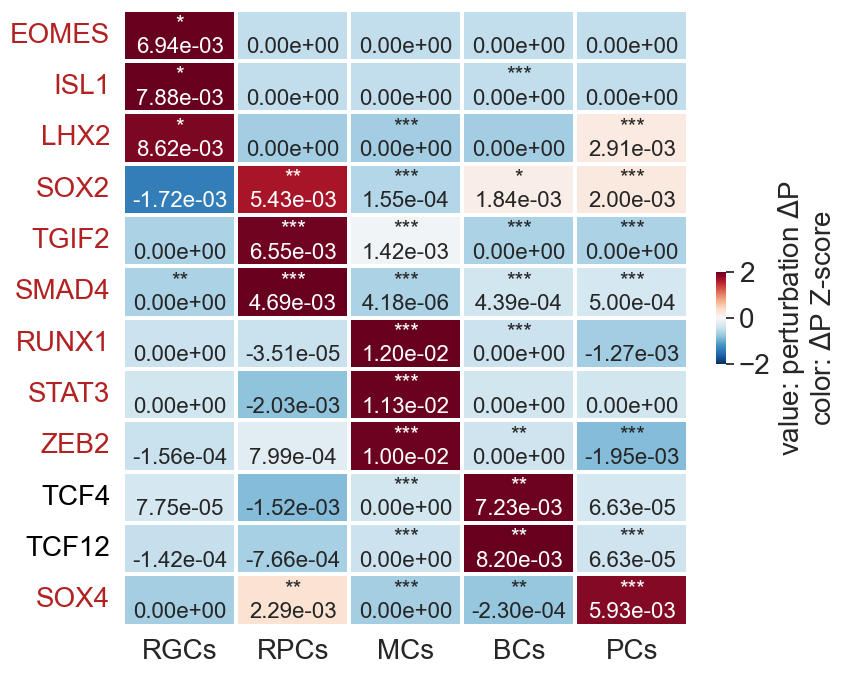

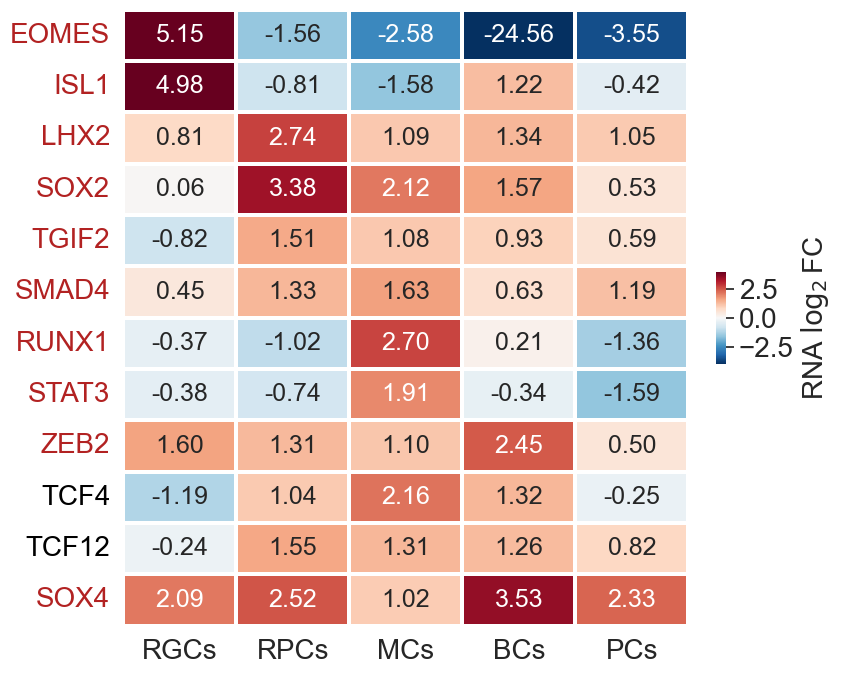

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

data_dir = "/path/data/perturbation_retina/gene_peak_links" 
cts = ['RGCs', 'RPCs', 'MCs', 'BCs', 'PCs']
tfs = ['EOMES', 'ISL1', 'LHX2', 'SOX2', 'TGIF2', 'SMAD4', 'RUNX1', 'STAT3', 'ZEB2', 'TCF4', 'TCF12', 'SOX4']

homer_files = [
    f"{data_dir}/peaks_with_RGCs_EOMES.txt",
    f"{data_dir}/peaks_with_RGCs_ISL1.txt",
    f"{data_dir}/peaks_with_RGCs_LHX2.txt",
    f"{data_dir}/peaks_with_RPCs_SOX2.txt",
    f"{data_dir}/peaks_with_RPCs_TGIF2.txt",
    f"{data_dir}/peaks_with_RPCs_SMAD4.txt",
    f"{data_dir}/peaks_with_MCs_RUNX1.txt",
    f"{data_dir}/peaks_with_MCs_STAT3.txt",
    f"{data_dir}/peaks_with_MCs_ZEB2.txt",
    f"{data_dir}/peaks_with_BCs_TCF4.txt",
    f"{data_dir}/peaks_with_BCs_TCF12.txt",
    f"{data_dir}/peaks_with_PCs_SOX4.txt"
]

USE_WEIGHTED_AVERAGE = False 

# ==========================================
# 1. Construct the Global Delta_P Dictionary Matrix Across Tissues
# ==========================================
ct_delta_dict = {}

for ct in cts:
    # Assume files exist; read the data (ensure you have these files locally for demonstration)
    try:
        link_results = pd.read_csv(data_dir + f"/{ct}_nearby_links.csv")
        filtered_links = link_results[link_results['dis'] == 5e5]
        pivot_df = filtered_links.pivot_table(
            index=['peak', 'gene_name'], 
            columns='type', 
            values='delta'
        ).reset_index()
        pivot_df = pivot_df.fillna(0)
        pivot_df['delta_diff'] = pivot_df[ct] - pivot_df['Others']
        peak_delta = pivot_df.groupby('peak')['delta_diff'].max()
        ct_delta_dict[ct] = peak_delta
    except FileNotFoundError:
        pass # Skip if local data is missing, preserving your original logic

global_delta_matrix = pd.DataFrame(ct_delta_dict).fillna(0)
print(f"total {len(global_delta_matrix)} Peaks")

# ==========================================
# 2. Parse HOMER Output Files to Establish Peak -> TF Mapping
# ==========================================
print("analyze HOMER Motif...")
homer_df_list = []

for file_path in homer_files:
    try:
        tmp_df = pd.read_csv(file_path, sep="\t")
        homer_df_list.append(tmp_df)
    except FileNotFoundError:
        pass

if len(homer_df_list) > 0:
    homer_df = pd.concat(homer_df_list, ignore_index=True)
    print(f"total {len(homer_df)} Motif")
    homer_df['TF'] = (
        homer_df['Motif Name']
        .str.split('(').str[0]
        .str.split('/').str[0]
        .str.upper()
    )
    homer_df = homer_df[homer_df['TF'].isin(tfs)]
    tf_peak_map = homer_df.groupby(['PositionID', 'TF'])['MotifScore'].max().reset_index()
    tf_peak_map.rename(columns={'PositionID': 'peak'}, inplace=True)
else:
    # Simulate an empty structure to prevent errors when local data is missing
    tf_peak_map = pd.DataFrame(columns=['peak', 'TF', 'MotifScore'])

# ==========================================
# 3. Merge Data and Calculate the Integrated TF Perturbation Score in Each Tissue
# ==========================================
global_delta_matrix_reset = global_delta_matrix.reset_index().rename(columns={'index': 'peak'})
merged_df = pd.merge(tf_peak_map, global_delta_matrix_reset, on='peak', how='inner')

def calculate_tf_score(group, ct_col):
    if USE_WEIGHTED_AVERAGE:
        weights = group['MotifScore'].values
        values = group[ct_col].values
        if np.sum(weights) == 0: return 0
        return np.average(values, weights=weights)
    else:
        return group[ct_col].mean()

heatmap_data = {}
for ct in cts:
    if not merged_df.empty:
        heatmap_data[ct] = merged_df.groupby('TF').apply(lambda g: calculate_tf_score(g, ct))
    else:
        # Automatically fill with 0s if there is no local data, ensuring the code runs and plots
        heatmap_data[ct] = pd.Series(0, index=tfs)

heatmap_df = pd.DataFrame(heatmap_data)
heatmap_df = heatmap_df.reindex(tfs).fillna(0)
print("\n--- heatmap data matrix ---")
print(heatmap_df)

# ==========================================
# 4. Data Preparation and Annotation Matrix Generation
# ==========================================
# log2fc values
rna_data = [
    [5.152062, 4.9753575, 0.80544317, 0.0596712, -0.8159889, 0.45252988, -0.37091509, -0.38166144, 1.604166, -1.1923478, -0.23506516, 2.094213], # RGCs
    [-1.5584759, -0.81286573, 2.7418497, 3.3786707, 1.5098916, 1.3257213, -1.0222416, -0.74285376, 1.3064973, 1.043288, 1.5504857, 2.5212233], # RPCs
    [-2.579605, -1.5786091, 1.0878439, 2.1202476, 1.0800256, 1.6315557, 2.69869, 1.9109776, 1.1001072, 2.158576, 1.3127689, 1.017702], # MCs
    [-24.561174, 1.2219872, 1.3388585, 1.5653864, 0.9328172, 0.6334014, 0.21485937, -0.33633867, 2.4462438, 1.3175786, 1.2551875, 3.531053], # BCs
    [-3.5457773, -0.42149454, 1.0486953, 0.5281354, 0.5916018, 1.1932256, -1.3582225, -1.5911672, 0.5006821, -0.25424504, 0.8225484, 2.3278034] # PCs
]
# q value (motif score significance)
qval_data = [
    [0.0439, 0.0402, 0.0401, 0.1838, 0.0630, 0.0041, 0.9479, 0.2490, 0.1315, 0.0059, 0.0000, 0.0756],
    [0.0131, 0.0000, 0.0677, 0.0020, 0.0002, 0.0000, 0.6263, 0.0056, 0.2983, 0.0834, 0.0518, 0.0058],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0000, 0.0001],
    [0.0841, 0.0000, 0.1259, 0.0118, 0.0004, 0.0004, 0.0006, 0.0010, 0.0019, 0.0024, 0.0024, 0.0061],
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0001, 0.0000]
]

rna_logfc_matrix = pd.DataFrame(rna_data, index=cts, columns=tfs).T
qval_matrix = pd.DataFrame(qval_data, index=cts, columns=tfs).T

def get_significance_stars(q, fc_val):
    if fc_val <= 0: return ""
    if pd.isna(q): return ""
    if q < 0.001:  return "***"
    elif q < 0.01: return "**"
    elif q < 0.05: return "*"
    else:          return ""

# Prepare separate annotation matrices for the two heatmaps
annot_matrix_peak = pd.DataFrame(index=rna_logfc_matrix.index, columns=rna_logfc_matrix.columns)
annot_matrix_rna = pd.DataFrame(index=rna_logfc_matrix.index, columns=rna_logfc_matrix.columns)

for row in rna_logfc_matrix.index:
    for col in rna_logfc_matrix.columns:
        fc_val = rna_logfc_matrix.loc[row, col]
        q_val = qval_matrix.loc[row, col]
        
        # Ensure heatmap_df has the corresponding row/col; fetch the value
        peak_val = heatmap_df.loc[row, col] if row in heatmap_df.index else 0
        
        # Significance stars remain consistent
        stars = get_significance_stars(q_val, fc_val)
        
        # Plot 1 text annotation: Significance stars + Peak value
        annot_matrix_peak.loc[row, col] = f"{stars}\n{peak_val:.2e}"
        
        # Plot 2 text annotation: RNA log2FC value only
        annot_matrix_rna.loc[row, col] = f"{fc_val:.2f}"

sns.set_theme(style="white")

# Helper function to highlight specific y-tick labels (Novel vs Known TFs)
def format_ytick_labels(ax, novel_tfs=['TCF4', 'TCF12']):
    """Format y-tick labels to distinguish novel TFs from known TFs."""
    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() in novel_tfs:
            # Highlight novel TFs in red and italic
            tick_label.set_color('black')
            # tick_label.set_fontstyle('italic')
            # tick_label.set_fontweight('bold')
        else:
            # Keep known TFs in black and bold
            tick_label.set_color('firebrick')
            # tick_label.set_fontweight('bold')

# ==========================================
# 5. Plot the First Heatmap: Peak Perturbation Delta
# ==========================================
# Minor adjustment to prevent NaN errors when calculating z-score on matrices with all zeros
heatmap_zscore = heatmap_df.apply(lambda x: zscore(x) if x.std() != 0 else x, axis=1)

plt.figure(figsize=(9, 8))
ax1 = sns.heatmap(
    data=heatmap_zscore,
    annot=annot_matrix_peak,   # Annotation text: Original heatmap_df value + significance stars
    cmap='RdBu_r',             
    center=0,
    vmin=-2,
    vmax=2.0,
    fmt="s",             
    linewidths=1.5,        
    linecolor='white',     
    cbar_kws={
        'label': 'value: perturbation $\Delta$P\ncolor: $\Delta$P Z-score',
        'shrink': 0.15,        
        'aspect': 10,          
        'pad': 0.04            
    },
    annot_kws={'size': 16}
)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
cbar.set_label('value: perturbation $\Delta$P\ncolor: $\Delta$P Z-score', fontsize=20)
# plt.title("Epigenetic Perturbation (Peak Delta)")
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=0, ha='center', fontsize=20)
plt.yticks(rotation=0, fontsize=20)
format_ytick_labels(ax1)
plt.savefig("/path/data/perturbation_retina/figs/TF_Tissue_Specific_Perturbation_Heatmap_1.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. Plot the Second Heatmap: RNA Expression (log2FC)
# ==========================================
plt.figure(figsize=(9, 8))
ax1 = sns.heatmap(
    data=rna_logfc_matrix,     # Colors based on: Original rna_data values
    annot=annot_matrix_rna,    # Annotation text: Original rna_data values
    cmap='RdBu_r',             
    center=0,
    vmin=-4,
    vmax=4,
    fmt="s",             
    linewidths=1.5,        
    linecolor='white',     
    cbar_kws={
        'label': 'RNA $\log_2$FC',
        'shrink': 0.15,        
        'aspect': 10,          
        'pad': 0.04            
    },
    annot_kws={'size': 18}
)
cbar = ax1.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
cbar.set_label('RNA $\log_2$FC', fontsize=20)
# plt.title("Transcriptomic Changes (RNA log2FC)")
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=0, ha='center', fontsize=20)
plt.yticks(rotation=0, fontsize=20)
format_ytick_labels(ax1)
plt.savefig("/path/data/perturbation_retina/figs/TF_Tissue_Specific_Perturbation_Heatmap_2.pdf", dpi=300, bbox_inches='tight')
plt.show()

## case study

### gene: ISLR2, tf: EOMES,ISL1,LHX2, ct: RGCs

Scanning GTF file, extracting ISLR2...
ISLR2 located between 74100311 and 74138540
Dynamic x-axis display range set to: 73699600 - 74587159


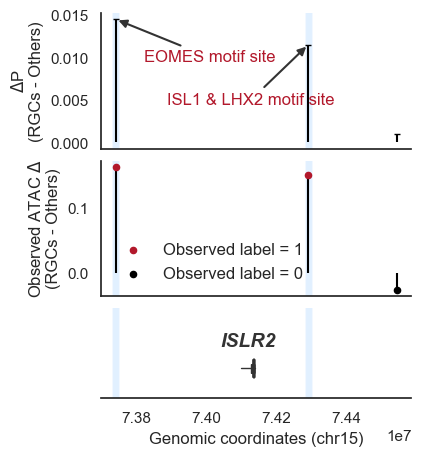

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
ct = 'RGCs'
target_gene = "ISLR2"
df = pd.read_csv(f'/path/data/perturbation_retina/gene_peak_links/{ct}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(4, 5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P ({ct} - Others)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel(f'$\Delta$P\n({ct} - Others)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel(f'Observed ATAC $\Delta$\n({ct} - Others)', fontsize=12)
ax2.legend(loc='lower left', frameon=False, fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=14, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=12)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr15-73739944-73741328', 'tf': 'EOMES'},
    {'peak': 'chr15-74290576-74292412', 'tf': 'ISL1 & LHX2'},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        if idx == 0:
            xt = mid + span * 0.1
            yt = row['delta_diff'].values[0] - 0.005
        else:
            xt = mid - span * 0.5
            yt = row['delta_diff'].values[0] - 0.007

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=12, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_retina/figs/{ct}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

<!-- 一、 皮肤/黑色素瘤模块（Skin）：表皮干性与 EMT 的终极主宰你划分给 Skin 的 5 个因子（PBX1, LEF1, TEAD1, TRPS1, ZEB2）堪称皮肤肿瘤发育生物学的“全明星阵容”。1. LEF1 (Wnt 通路核心效应分子)组织相关性： 皮肤毛囊干细胞的发育、黑色素细胞的增殖，绝对依赖于 Wnt/$\beta$-catenin 通路，而 LEF1 是该通路入核后的终极开关。在黑色素瘤（Melanoma）中，LEF1 异常活跃以维持癌细胞的干性。证据检索： 在 PubMed 检索 "LEF1 Wnt signaling hair follicle melanoma"。经典文献常发表于 Nature, Genes & Development。2. TEAD1 (Hippo 通路靶基因)组织相关性： 正常皮肤基底层的无限增殖需要 YAP/TEAD 复合体。在皮肤鳞状细胞癌（cSCC）中，TEAD1 被高强度劫持，导致表皮细胞疯狂增殖并丧失分化能力。证据检索： "YAP TEAD1 epidermal proliferation squamous cell carcinoma"。3. ZEB2 (黑素细胞分化的特异性开关)组织相关性： 这是你数据里极具深度的一个发现！在黑色素瘤中，存在一个著名的 "ZEB1/ZEB2 开关效应"。ZEB2 高表达是维持黑色素细胞分化和增殖的标志。顶级实锤文献： Caramel, J. et al. "A switch in the expression of embryonic EMT-inducers drives the development of malignant melanoma." Cancer Cell (2013).4. TRPS1 (毛发-皮肤附属器发育关键基因)组织相关性： TRPS1 全称是“毛发-鼻-指骨综合征型 1”。它的先天突变会直接导致严重的毛发发育不良和皮肤结构异常。它在表观层面主导皮肤，是极其完美的逻辑闭环。证据检索： "TRPS1 hair follicle epidermal development"。5. PBX1 (神经嵴先锋因子)组织相关性： 皮肤的黑色素细胞起源于胚胎期的“神经嵴（Neural Crest）”。PBX1 是著名的先锋因子（Pioneer Factor），决定了神经嵴细胞的命运走向。证据检索： "PBX1 neural crest melanoma pioneer factor"。二、 子宫/子宫内膜癌模块（Uterus）：炎症与代谢重塑微环境将 STAT1 和 CREB5 划给子宫，展示了模型对组织微环境（Microenvironment）的强大洞察力。6. STAT1 (干扰素/炎症核心)组织相关性： 子宫内膜（Endometrium）是人体内唯一会发生周期性剥落、修复和剧烈免疫重塑的组织。子宫内膜癌的发生高度依赖于局部的炎症微环境（Inflammatory microenvironment）。STAT1 作为干扰素响应的核心因子，在子宫内膜的容受性重塑和肿瘤微环境免疫逃逸中起主导作用。证据检索： "STAT1 endometrial cancer inflammation microenvironment"。7. CREB5 (cAMP 通路响应者)组织相关性： 子宫内膜在孕激素刺激下发生“蜕膜化（Decidualization）”，这一过程极其依赖于局部的 cAMP/PKA 信号通路。CREB 家族（cAMP 响应元件结合蛋白）正是开启这一表观重塑的核心钥匙。证据检索： "CREB cAMP pathway endometrial decidualization cancer"。三、 乳腺癌模块（Breast）：教科书级的金标准8. PGR (孕激素受体, Progesterone Receptor)组织相关性： 这个不需要过多解释。乳腺癌临床分型最核心的“三大件”就是 ER（雌激素受体）、PR（即 PGR） 和 HER2。PGR 是乳腺腔面型（Luminal）肿瘤的绝对表观与转录主宰。证明来源： 任何一本权威的《肿瘤学》或《病理学》教科书，或检索 "PGR Progesterone Receptor Luminal Breast Cancer"。这颗星号和深红色就是你算法准确率的“定海神针”。四、 结肠癌模块（Colon）：肠道稳态的掌控者9. FOXP1 (Forkhead Box P1)组织相关性： 正常结肠黏膜的稳态维持以及结肠癌（Colorectal Cancer, CRC）的发生中，FOXP1 扮演着极其关键的角色。它经常与 Wnt/$\beta$-catenin 通路发生互作，在肠道干细胞龛（Stem cell niche）的维持和肿瘤恶性转化中起重要调控作用。证据检索： "FOXP1 colorectal cancer proliferation Wnt"。五、 胰腺癌模块（Pancreas）：致命转移的发动机10. ZEB1 (终极 EMT 驱动因子)组织相关性： 胰腺导管腺癌（PDAC）被称为“癌中之王”，其最致命的特征就是极早期的侵袭和远端转移。而在 PDAC 中，ZEB1 是公认的触发上皮-间质转化（EMT）、驱动转移和化疗耐药的终极 Master Regulator。你的模型在胰腺里精准锁定了 ZEB1 的表观和转录双向激活。顶级实锤文献： 德国 Thomas Brabletz 课题组在 Nature, Cancer Cell 等期刊上发表过大量关于 ZEB1 在胰腺癌中核心驱动作用的文章（例如检索 "ZEB1 EMT pancreatic cancer Brabletz"）。 -->

### gene: ADCY1, tf: ISL1, ct: RGCs

Scanning GTF file, extracting ADCY1...
ADCY1 located between 45574140 and 45723116
Dynamic x-axis display range set to: 45070605 - 45962538


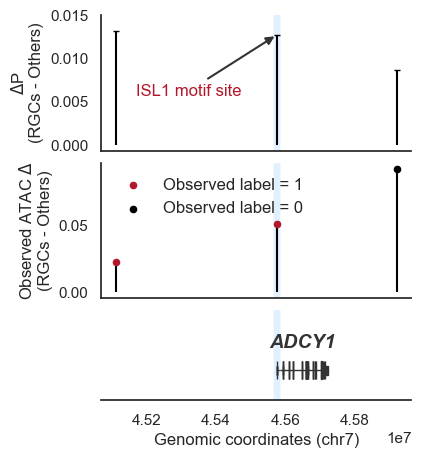

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
ct = 'RGCs'
target_gene = "ADCY1"

df = pd.read_csv(f'/path/data/perturbation_retina/gene_peak_links/{ct}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(4, 5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P ({ct} - Others)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel(f'$\Delta$P\n({ct} - Others)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_yticks([0.000, 0.005, 0.01, 0.015])

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel(f'Observed ATAC $\Delta$\n({ct} - Others)', fontsize=12)
ax2.legend(loc='upper left', frameon=False, fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=14, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=12)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr7-45574159-45576328', 'tf': 'ISL1'},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        xt = mid - span * 0.5
        yt = row['delta_diff'].values[0] - 0.007

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=12, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_retina/figs/{ct}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

### gene: CKB, tf: SOX2,TGIF2,SMAD4, ct: RPCs

Scanning GTF file, extracting CKB...


CKB located between 103519667 and 103522833
Dynamic x-axis display range set to: 103030006 - 103622008


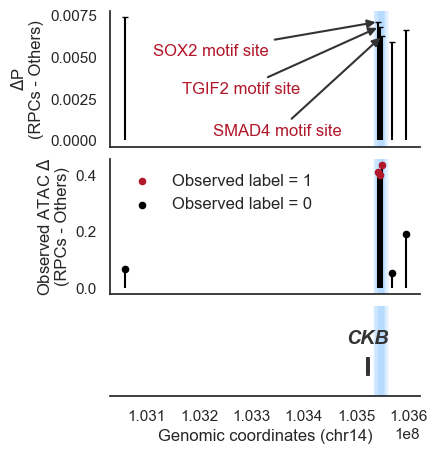

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
ct = 'RPCs'
target_gene = "CKB"
df = pd.read_csv(f'/path/data/perturbation_retina/gene_peak_links/{ct}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(4, 5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P ({ct} - Others)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel(f'$\Delta$P\n({ct} - Others)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel(f'Observed ATAC $\Delta$\n({ct} - Others)', fontsize=12)
ax2.legend(loc='upper left', frameon=False, fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=14, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=12)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr14-103542014-103542609', 'tf': 'SOX2'},
    {'peak': 'chr14-103544192-103545015', 'tf': 'TGIF2'},
    {'peak': 'chr14-103549858-103550384', 'tf': 'SMAD4'},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        if idx == 0:
            xt = mid - span * 0.8
            yt = row['delta_diff'].values[0] - 0.002
        elif idx == 1:
            xt = mid - span * 0.7
            yt = row['delta_diff'].values[0] - 0.004
        else:
            xt = mid - span * 0.6
            yt = row['delta_diff'].values[0] - 0.006

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=12, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_retina/figs/{ct}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

### gene: COL4A1, tf: RUNX1,STAT3, ct: MCs

Scanning GTF file, extracting COL4A1...
COL4A1 located between 110148963 and 110307202
Dynamic x-axis display range set to: 110128281 - 110583271


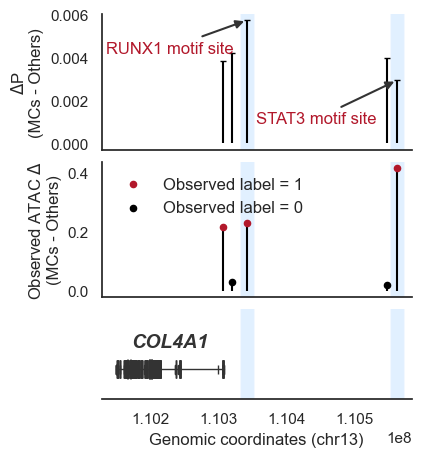

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
ct = 'MCs'
target_gene = "COL4A1"
df = pd.read_csv(f'/path/data/perturbation_retina/gene_peak_links/{ct}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(4, 5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P ({ct} - Others)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel(f'$\Delta$P\n({ct} - Others)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel(f'Observed ATAC $\Delta$\n({ct} - Others)', fontsize=12)
ax2.legend(loc='upper left', frameon=False, fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=14, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=12)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chr13-110340602-110342214', 'tf': 'RUNX1'},
    {'peak': 'chr13-110560607-110562590', 'tf': 'STAT3'}
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        if idx == 0:
            xt = mid - span * 0.5
            yt = row['delta_diff'].values[0] - 0.0015
        else:
            xt = mid - span * 0.5
            yt = row['delta_diff'].values[0] - 0.002

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=12, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_retina/figs/{ct}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

### gene: GPM6B, tf: ZEB2, ct: MCs

Scanning GTF file, extracting GPM6B...
GPM6B located between 13770939 and 13938638
Dynamic x-axis display range set to: 13637851 - 13953908


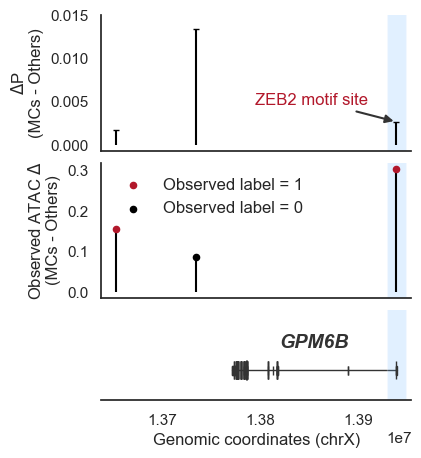

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import numpy as np

def parse_gencode_gtf(gtf_path, target_gene):
    """
    Parse GTF file line-by-line to extract CDS, UTR, and Exon coordinates for a target gene.
    Returns: gene_start, gene_end, elements_dict
    """
    elements = {'CDS': [], 'UTR': [], 'exon': []}
    gene_start, gene_end = float('inf'), 0

    print(f"Scanning GTF file, extracting {target_gene}...")
    with open(gtf_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            
            # Quick string check to accelerate filtering
            if target_gene not in line:
                continue
                
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
                
            feature_type = parts[2]
            attributes = parts[8]
            
            # Precise matching for gene_name
            if f'gene_name "{target_gene}"' in attributes:
                start, end = int(parts[3]), int(parts[4])
                
                # Record overall genomic span for the gene
                gene_start = min(gene_start, start)
                gene_end = max(gene_end, end)
                
                if feature_type in elements:
                    elements[feature_type].append((start, end))
                    
    print(f"{target_gene} located between {gene_start} and {gene_end}")
    return gene_start, gene_end, elements

# ==========================================
# 1. Load Data
# ==========================================
ct = 'MCs'
target_gene = "GPM6B"
df = pd.read_csv(f'/path/data/perturbation_retina/gene_peak_links/{ct}_results.csv', index_col=0)
df = df[df['gene_name'] == target_gene]

# Parse peak genomic coordinates
df[['chr', 'start', 'end']] = df['peak'].str.split('-', expand=True)
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int)
df['midpoint'] = (df['start'] + df['end']) / 2

# Extract gene structure from GTF
gtf_file_path = "/path/data/gencode.v47.annotation.gtf" 
gene_start, gene_end, elements = parse_gencode_gtf(gtf_file_path, target_gene)

# ==========================================
# 2. Dynamic Genomic Coordinate Range Calculation
# ==========================================
# Collect min and max positions from both peaks and gene annotations
peak_min = df['start'].min()
peak_max = df['end'].max()

all_starts = [peak_min]
all_ends = [peak_max]

if gene_start != float('inf') and gene_end > 0:
    all_starts.append(gene_start)
    all_ends.append(gene_end)

raw_x_min = min(all_starts)
raw_x_max = max(all_ends)

# Add a 5% padding buffer on both sides for visual balance
span = raw_x_max - raw_x_min
padding = span * 0.05
x_min = int(raw_x_min - padding)
x_max = int(raw_x_max + padding)

print(f"Dynamic x-axis display range set to: {x_min} - {x_max}")

# ==========================================
# 3. Initialize Plot Grid
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(4, 5), sharex=True, 
    gridspec_kw={'height_ratios': [1.5, 1.5, 1.0]}
)
plt.subplots_adjust(hspace=0.1)

# ==========================================
# Track 1: Delta P ({ct} - Others)
# ==========================================
markerline, stemlines, baseline = ax1.stem(df['midpoint'], df['delta_diff'], basefmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)
plt.setp(markerline, 'color', 'black', 'markersize', 4, marker='_')
ax1.set_ylabel(f'$\Delta$P\n({ct} - Others)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_yticks([0.000, 0.005, 0.01, 0.015])

# ==========================================
# Track 2: Observed Accessibility Delta (obs_atac_diff)
# ==========================================
markerline, stemlines, baseline = ax2.stem(df['midpoint'], df['obs_atac_diff'], basefmt=" ", markerfmt=" ")
plt.setp(stemlines, 'color', 'black', 'linewidth', 1.5)

for lbl, color, marker_label in [(1, '#B2182B', 'Observed label = 1'), 
                                 (0, 'black', 'Observed label = 0')]:
    subset = df[df['label'] == lbl]
    if not subset.empty:
        ax2.scatter(subset['midpoint'], subset['obs_atac_diff'],
                    s=20, color=color, zorder=10, label=marker_label)

ax2.set_ylabel(f'Observed ATAC $\Delta$\n({ct} - Others)', fontsize=12)
ax2.legend(loc='upper left', frameon=False, fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ==========================================
# Track 3: Marker Gene Annotation Track
# ==========================================
if gene_start is not None and gene_end > 0:
    # 1. Intron backbone
    ax3.plot([gene_start, gene_end], [0, 0], color='#333333', linewidth=1.0, zorder=1)
    
    # 2. UTR regions
    for start, end in elements['UTR']:
        rect = patches.Rectangle((start, -0.15), end - start, 0.3, color='#333333', zorder=2)
        ax3.add_patch(rect)
        
    # 3. CDS regions
    for start, end in elements['CDS']:
        rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=3)
        ax3.add_patch(rect)
        
    # Fallback to general Exons if CDS/UTR tags are absent
    if not elements['CDS'] and not elements['UTR']:
        for start, end in elements['exon']:
            rect = patches.Rectangle((start, -0.3), end - start, 0.6, color='#333333', zorder=2)
            ax3.add_patch(rect)

# Gene label text
ax3.text((gene_start + gene_end) / 2, 0.6, target_gene, ha='center', va='bottom', 
         fontsize=14, fontstyle='italic', fontweight='bold', color='#333333')

ax3.set_ylim(-1, 2)
chr_name = df['chr'].iloc[0] if not df.empty else 'genome'
ax3.set_xlabel(f'Genomic coordinates ({chr_name})', fontsize=12)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_yticks([])

# ==========================================
# Highlight Target TF motif site Across All Tracks
# ==========================================
tf_bindings = [
    {'peak': 'chrX-13937409-13939542', 'tf': 'ZEB2'},
]

for idx, b in enumerate(tf_bindings):
    row = df[df['peak'] == b['peak']]
    if not row.empty:
        mid = row['midpoint'].values[0]
        # Highlight regions across all tracks
        for ax in [ax1, ax2, ax3]:
            ax.add_patch(patches.Rectangle((mid - 10000, -100), 20000, 200, 
                                           facecolor='#6DB8FF', alpha=0.2))
            
        xt = mid - span * 0.5
        yt = row['delta_diff'].values[0] + 0.002

        ax1.annotate(f"{b['tf']} motif site", 
                    xy=(mid, row['delta_diff'].values[0]),
                    xytext=(xt, yt),
                    arrowprops=dict(facecolor='black', arrowstyle='-|>', lw=1.5, color='#333333'),
                    fontsize=12, color='#B2182B')

# Apply final dynamic X-axis limits
ax3.set_xlim(x_min, x_max)

offset_text = ax3.xaxis.get_offset_text()
offset_text.set_position((1.0, -0.1))

plt.grid(False)
plt.savefig(f"/path/data/perturbation_retina/figs/{ct}_{target_gene}_motif_peak_region.pdf", dpi=300, bbox_inches='tight')
plt.show()